# PreProcessing: Deteksi Outlier & Imputasi Missing Value serta Ekstraksi Fitur Pada NO2

## Deteksi Outliers pada Data Kualitas Udara di Kecamatan Widodaren

In [11]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np


df = pd.read_csv("KualitasUdaraWidodaren.csv")
df.columns = df.columns.str.strip()  

fitur_polutan = ['CO', 'NO2', 'SO2']

print("=== PROSES DETEKSI & PENANGANAN OUTLIER (METODE IQR) ===\n")

for kolom in fitur_polutan:
    if kolom in df.columns:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[
            (df[kolom] < lower_bound) | 
            (df[kolom] > upper_bound)
        ]

        print(f"=== Parameter: {kolom} ===")
        print(f"Q1  : {Q1:.6f}")
        print(f"Q3  : {Q3:.6f}")
        print(f"IQR : {IQR:.6f}")
        print(f"Batas bawah : {lower_bound:.6f}")
        print(f"Batas atas  : {upper_bound:.6f}")
        print(f"Jumlah Outlier : {len(outliers_iqr)}")
        if len(outliers_iqr) > 0:
            print(outliers_iqr[['date', kolom]].head())

        # Outlier diubah jadi NaN langsung di df (ini yang membuat file benar-benar berubah)
        df.loc[(df[kolom] < lower_bound) | (df[kolom] > upper_bound), kolom] = np.nan
        print(f"-> Outlier pada kolom '{kolom}' sudah diubah menjadi NaN.\n")
    else:
        print(f"=== Parameter: {kolom} ===")
        print(f"Kolom '{kolom}' tidak ditemukan di DataFrame.\n")

    print("-" * 35 + "\n")

# Simpan hasil akhir ke file baru
output_file = "KualitasUdaraWidodaren_NoOutlier.csv"
df.to_csv(output_file, index=False)

print(f"=== SELESAI ===")
print(f"Total baris data     : {len(df)}")
print(f"Sisa missing value   : {df[fitur_polutan].isnull().sum().sum()} (outlier + missing asli)")
print(f"File hasil disimpan  : {output_file}")

=== PROSES DETEKSI & PENANGANAN OUTLIER (METODE IQR) ===

=== Parameter: CO ===
Q1  : 0.027038
Q3  : 0.032092
IQR : 0.005054
Batas bawah : 0.019456
Batas atas  : 0.039673
Jumlah Outlier : 3
                         date        CO
38   2025-10-07T00:00:00.000Z  0.041322
68   2025-11-06T00:00:00.000Z  0.019267
363  2026-08-28T00:00:00.000Z  0.040650
-> Outlier pada kolom 'CO' sudah diubah menjadi NaN.

-----------------------------------

=== Parameter: NO2 ===
Q1  : 0.000020
Q3  : 0.000029
IQR : 0.000009
Batas bawah : 0.000006
Batas atas  : 0.000042
Jumlah Outlier : 8
                         date           NO2
4    2025-09-03T00:00:00.000Z  4.200000e-05
62   2025-10-31T00:00:00.000Z  3.980000e-06
132  2026-01-09T00:00:00.000Z  4.290000e-05
147  2026-01-24T00:00:00.000Z -4.950000e-06
232  2026-04-19T00:00:00.000Z  3.770000e-07
-> Outlier pada kolom 'NO2' sudah diubah menjadi NaN.

-----------------------------------

=== Parameter: SO2 ===
Q1  : -0.000035
Q3  : 0.000097
IQR : 0.000131
B

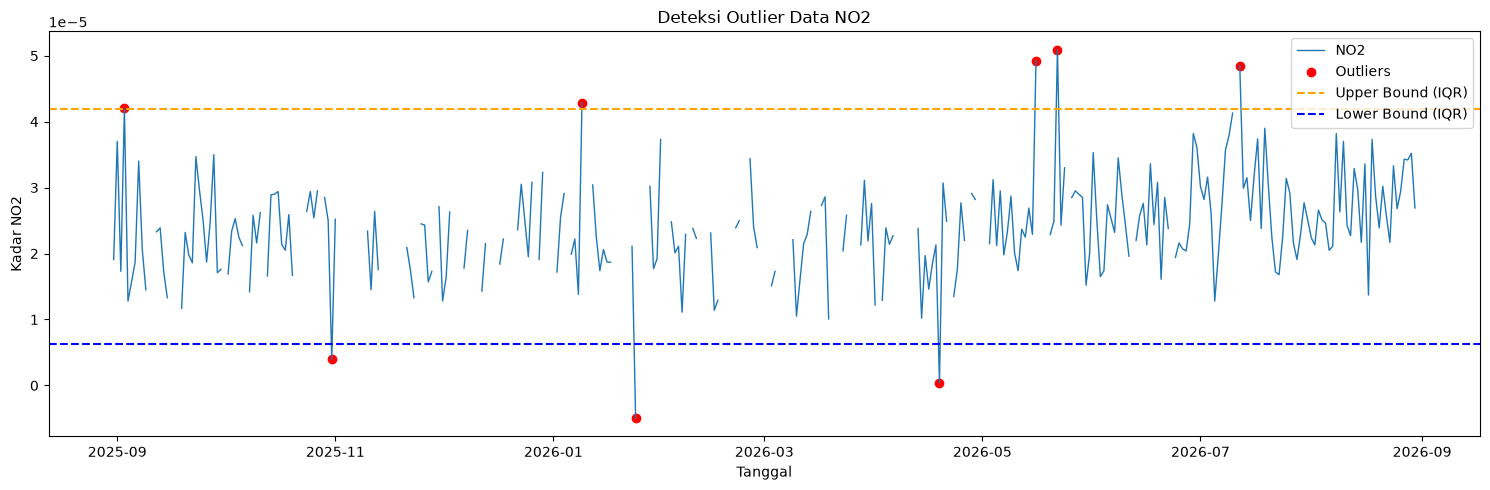

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca file CSV
df = pd.read_csv("NO2InWidodaren.csv")

# Mengubah date menjadi format tanggal
df["date"] = pd.to_datetime(df["date"])

# Menghitung Q1 dan Q3
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengambil data yang dianggap outlier
outliers_iqr = df[
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound)
]

# Membuat grafik
plt.figure(figsize=(15, 5))

# Grafik seluruh data NO2
plt.plot(
    df["date"],
    df["NO2"],
    label="NO2",
    linewidth=1
)

# Menampilkan outlier dengan titik merah
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["NO2"],
    color="red",
    marker="o",
    label="Outliers",
)

# Garis batas atas
plt.axhline(
    upper_bound,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)",
)

# Garis batas bawah
plt.axhline(
    lower_bound,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)",
)

plt.title("Deteksi Outlier Data NO2")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

plt.show()

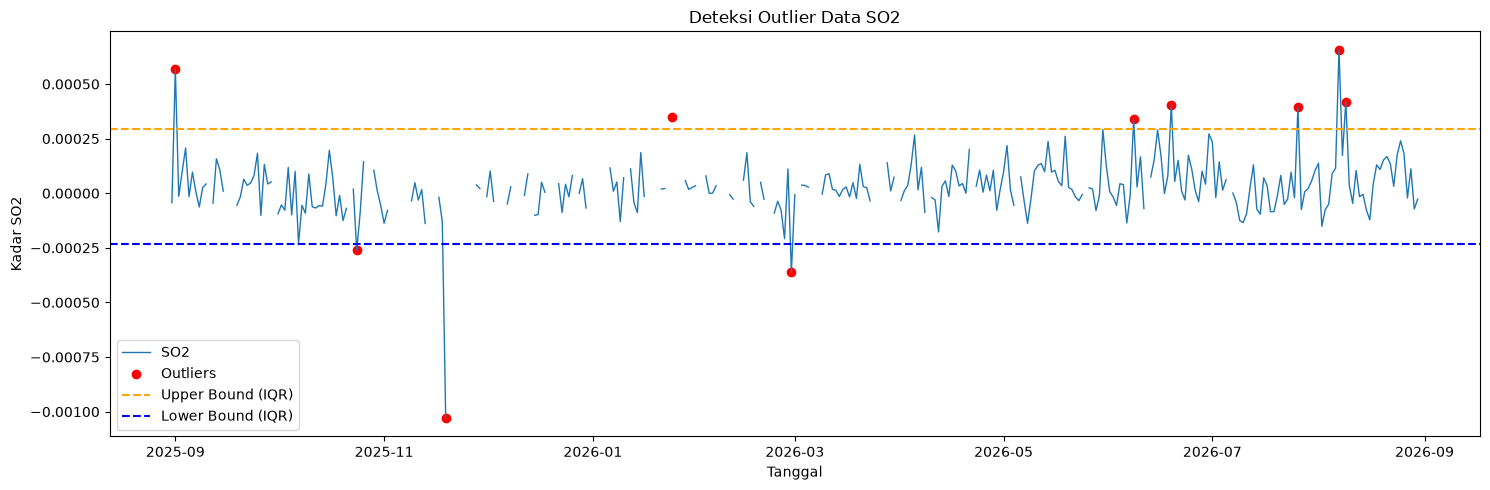

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca file CSV
df = pd.read_csv("SO2InWidodaren.csv")

# Mengubah date menjadi format tanggal
df["date"] = pd.to_datetime(df["date"])

# Menghitung Q1 dan Q3
Q1 = df["SO2"].quantile(0.25)
Q3 = df["SO2"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengambil data yang dianggap outlier
outliers_iqr = df[
    (df["SO2"] < lower_bound) |
    (df["SO2"] > upper_bound)
]

# Membuat grafik
plt.figure(figsize=(15, 5))

# Grafik seluruh data SO2
plt.plot(
    df["date"],
    df["SO2"],
    label="SO2",
    linewidth=1
)

# Menampilkan outlier dengan titik merah
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["SO2"],
    color="red",
    marker="o",
    label="Outliers",
)

# Garis batas atas
plt.axhline(
    upper_bound,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)",
)

# Garis batas bawah
plt.axhline(
    lower_bound,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)",
)

plt.title("Deteksi Outlier Data SO2")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()

plt.show()

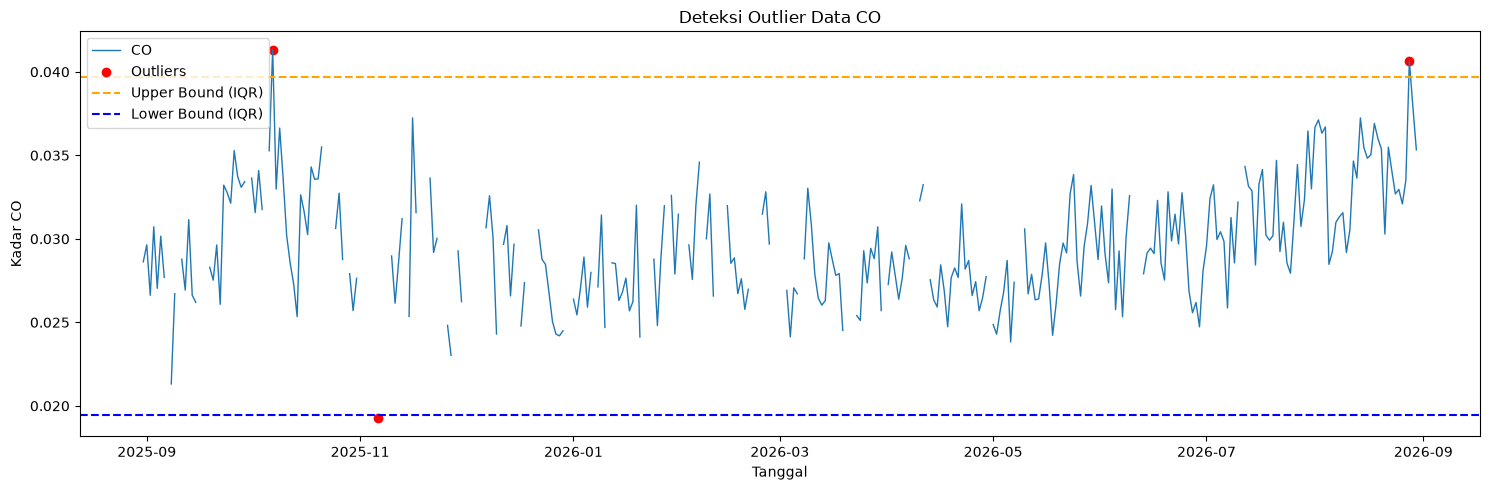

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca file CSV
df = pd.read_csv("COInWidodaren.csv")

# Mengubah date menjadi format tanggal
df["date"] = pd.to_datetime(df["date"])

# Menghitung Q1 dan Q3
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengambil data yang dianggap outlier
outliers_iqr = df[
    (df["CO"] < lower_bound) |
    (df["CO"] > upper_bound)
]

# Membuat grafik
plt.figure(figsize=(15, 5))

# Grafik seluruh data CO
plt.plot(
    df["date"],
    df["CO"],
    label="CO",
    linewidth=1
)

# Menampilkan outlier dengan titik merah
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["CO"],
    color="red",
    marker="o",
    label="Outliers",
)

# Garis batas atas
plt.axhline(
    upper_bound,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)",
)

# Garis batas bawah
plt.axhline(
    lower_bound,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)",
)

plt.title("Deteksi Outlier Data CO")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()

plt.show()

### 2. Deteksi Outliers pada NO2 Untuk Ekstraksi Fitur

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("SO2InWidodaren.csv")
df.columns = df.columns.str.strip()  
fitur_polutan = ['SO2']

print("=== PROSES DETEKSI & PENANGANAN OUTLIER NO2 (METODE IQR) ===\n")

for kolom in fitur_polutan:
    if kolom in df.columns:
        df[kolom] = pd.to_numeric(df[kolom], errors='coerce')

        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[
            (df[kolom] < lower_bound) | 
            (df[kolom] > upper_bound)
        ]

        print(f"=== Parameter: {kolom} ===")
        print(f"Q1  : {Q1:.6f}")
        print(f"Q3  : {Q3:.6f}")
        print(f"IQR : {IQR:.6f}")
        print(f"Batas bawah : {lower_bound:.6f}")
        print(f"Batas atas  : {upper_bound:.6f}")
        print(f"Jumlah Outlier : {len(outliers_iqr)}")
        if len(outliers_iqr) > 0:
            print(outliers_iqr[['date', kolom]].head())

        df.loc[(df[kolom] < lower_bound) | (df[kolom] > upper_bound), kolom] = np.nan
        print(f"-> Outlier pada kolom '{kolom}' sudah diubah menjadi NaN.\n")
    else:
        print(f"=== Parameter: {kolom} ===")
        print(f"Kolom '{kolom}' tidak ditemukan di DataFrame.\n")

    print("-" * 35 + "\n")

output_file = "SO2Widodaren_NoOutlier.csv"
df.to_csv(output_file, index=False)

print(f"=== SELESAI ===")
print(f"Total baris data     : {len(df)}")
print(f"Sisa missing value   : {df['SO2'].isnull().sum()} (outlier + missing asli)")
print(f"File hasil disimpan  : {output_file}")

=== PROSES DETEKSI & PENANGANAN OUTLIER NO2 (METODE IQR) ===

=== Parameter: SO2 ===
Q1  : -0.000035
Q3  : 0.000097
IQR : 0.000131
Batas bawah : -0.000232
Batas atas  : 0.000294
Jumlah Outlier : 10
                          date       SO2
2    2025-09-01 00:00:00+00:00  0.000569
55   2025-10-24 00:00:00+00:00 -0.000260
81   2025-11-19 00:00:00+00:00 -0.001029
147  2026-01-24 00:00:00+00:00  0.000351
182  2026-02-28 00:00:00+00:00 -0.000361
-> Outlier pada kolom 'SO2' sudah diubah menjadi NaN.

-----------------------------------

=== SELESAI ===
Total baris data     : 366
Sisa missing value   : 74 (outlier + missing asli)
File hasil disimpan  : SO2Widodaren_NoOutlier.csv


### 3. Merubah Outliers NO2 Menjadi NaN serta Imputasi Missing Values dan Outliers (NaN)

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2InWidodaren.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

cols = ['NO2']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti nilai di luar batas IQR menjadi NaN
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

df_clean = df.interpolate(method='time').ffill().bfill()

# 4. Cek hasil akhir
print("Sisa Missing Value:", df_clean.isnull().sum().sum())
df_clean.to_csv('NO2-Widodaren-Clean.csv')

Sisa Missing Value: 0


### 4. Install Library TSFEL Untuk Ekstraksi Fitur

In [19]:
pip install tsfel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 5. Ekstraksi Menjadi 68 Fitur 

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2-Widodaren-Clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}-Widodaren-TSFEL.csv', index=False)

In [ ]:
df_features = pd.read_csv("NO2-Widodaren-TSFEL.csv")
df_features.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,2.173853e-07,0.008632,2.0,5.955761e-10,196.997143,0.000038,0.000024,0.000023,0.00001,0.000006,...,0.152316,0.642335,5.870496e-11,0.001716,0.000001,0.000009,2.181052,0.000009,8.221539e-11,0.0


In [ ]:
df_features = pd.read_csv("SO2-Widodaren-TSFEL.csv")
df_features.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000002,0.019639,1.0,6.632817e-09,204.82865,0.00024,0.000022,0.000017,-0.000177,0.000078,...,0.147906,0.227951,1.039525e-08,0.025164,0.000004,0.000098,2.188077,0.000098,9.716554e-09,124.0


In [ ]:
df_features = pd.read_csv("CO-Widodaren-TSFEL.csv")
df_features.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.323233,10.78444,4.0,0.000886,186.440948,0.037934,0.029553,0.029181,0.021309,0.003125,...,0.134168,0.506234,0.000014,0.746127,0.001805,0.007579,2.139069,0.007337,0.000062,0.0


### 6. Mengelompokkan Fitur Hasil Ekstraksi Berdasarkan Domain

In [ ]:
import pandas as pd

# ---------- 1. Muat hasil ekstraksi TSFEL ----------
df_features = pd.read_csv('NO2-Widodaren-TSFEL.csv')

# ---------- 2. Mapping resmi fitur -> domain (sesuai features.json TSFEL) ----------
FEATURE_DOMAIN_MAP = {
    # Statistical (21)
    "abs_energy": "statistical", "average_power": "statistical", "calc_max": "statistical",
    "calc_mean": "statistical", "calc_median": "statistical", "calc_min": "statistical",
    "calc_std": "statistical", "calc_var": "statistical", "ecdf": "statistical",
    "ecdf_percentile": "statistical", "ecdf_percentile_count": "statistical",
    "ecdf_slope": "statistical", "entropy": "statistical", "hist_mode": "statistical",
    "interq_range": "statistical", "kurtosis": "statistical", "mean_abs_deviation": "statistical",
    "median_abs_deviation": "statistical", "pk_pk_distance": "statistical", "rms": "statistical",
    "skewness": "statistical",

    # Temporal (15)
    "auc": "temporal", "autocorr": "temporal", "calc_centroid": "temporal",
    "distance": "temporal", "lempel_ziv": "temporal", "mean_abs_diff": "temporal",
    "mean_diff": "temporal", "median_abs_diff": "temporal", "median_diff": "temporal",
    "negative_turning": "temporal", "neighbourhood_peaks": "temporal",
    "positive_turning": "temporal", "slope": "temporal", "sum_abs_diff": "temporal",
    "zero_cross": "temporal",

    # Spectral (26)
    "fundamental_frequency": "spectral", "human_range_energy": "spectral", "lpcc": "spectral",
    "max_frequency": "spectral", "max_power_spectrum": "spectral", "median_frequency": "spectral",
    "mfcc": "spectral", "power_bandwidth": "spectral", "spectral_centroid": "spectral",
    "spectral_decrease": "spectral", "spectral_distance": "spectral", "spectral_entropy": "spectral",
    "spectral_kurtosis": "spectral", "spectral_positive_turning": "spectral",
    "spectral_roll_off": "spectral", "spectral_roll_on": "spectral", "spectral_skewness": "spectral",
    "spectral_slope": "spectral", "spectral_spread": "spectral", "spectral_variation": "spectral",
    "spectrogram_mean_coeff": "spectral", "wavelet_abs_mean": "spectral", "wavelet_energy": "spectral",
    "wavelet_entropy": "spectral", "wavelet_std": "spectral", "wavelet_var": "spectral",

    # Fractal (6) - domain terpisah di TSFEL
    "dfa": "fractal", "higuchi_fractal_dimension": "fractal", "hurst_exponent": "fractal",
    "maximum_fractal_length": "fractal", "mse": "fractal", "petrosian_fractal_dimension": "fractal",
}

# ---------- 3. Kelompokkan kolom sesuai domain ----------
domain_columns = {"statistical": [], "temporal": [], "spectral": [], "fractal": [], "unknown": []}
for col in df_features.columns:
    domain = FEATURE_DOMAIN_MAP.get(col, "unknown")
    domain_columns[domain].append(col)

for domain, cols in domain_columns.items():
    print(f"{domain.upper()} ({len(cols)}): {cols}")

# ---------- 4. (Opsional) Pisah jadi DataFrame terpisah per domain ----------
df_statistical = df_features[domain_columns["statistical"]]
df_temporal = df_features[domain_columns["temporal"]]
df_spectral = df_features[domain_columns["spectral"]]
df_fractal = df_features[domain_columns["fractal"]]

# ---------- 5. (Opsional) Simpan masing-masing sebagai CSV terpisah ----------
df_statistical.to_csv('NO2_fitur_statistical.csv', index=False)
df_temporal.to_csv('NO2_fitur_temporal.csv', index=False)
df_spectral.to_csv('NO2_fitur_spectral.csv', index=False)
df_fractal.to_csv('NO2_fitur_fractal.csv', index=False)

STATISTICAL (21): ['abs_energy', 'average_power', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'hist_mode', 'interq_range', 'kurtosis', 'mean_abs_deviation', 'median_abs_deviation', 'pk_pk_distance', 'rms', 'skewness']
TEMPORAL (15): ['auc', 'autocorr', 'calc_centroid', 'distance', 'lempel_ziv', 'mean_abs_diff', 'mean_diff', 'median_abs_diff', 'median_diff', 'negative_turning', 'neighbourhood_peaks', 'positive_turning', 'slope', 'sum_abs_diff', 'zero_cross']
SPECTRAL (26): ['fundamental_frequency', 'human_range_energy', 'lpcc', 'max_frequency', 'max_power_spectrum', 'median_frequency', 'mfcc', 'power_bandwidth', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 'spectrogram_mean_

## Penjelasan Domain TSFEL

TSFEL (_Time Series Feature Extraction Library_) mengekstraksi karakteristik sinyal dari beberapa sudut pandang. Pada analisis ini, 365 nilai NO2 harian diperlakukan sebagai satu sinyal satu dimensi. Karena `fs = 1`, satu sampel merepresentasikan satu hari dan frekuensi yang dihasilkan fitur spectral dibaca dalam satuan siklus per hari. Dengan demikian, fitur TSFEL bukan 68 pengamatan baru, melainkan 68 ringkasan matematis dari satu deret waktu NO2.

Pembagian domain penting karena setiap domain menjawab pertanyaan yang berbeda:

1. **Statistical** menjawab: bagaimana distribusi dan besarnya nilai NO2?
2. **Temporal** menjawab: bagaimana nilai NO2 berubah menurut urutan hari?
3. **Spectral** menjawab: apakah terdapat pola berulang atau energi pada frekuensi tertentu?
4. **Fractal** menjawab: seberapa kompleks, kasar, dan memiliki memori jangka panjang sinyal tersebut?

Nilai fitur harus dibandingkan dengan hati-hati. Fitur dalam satu domain dapat memiliki skala, satuan, dan sensitivitas yang berbeda. Selain itu, beberapa fitur TSFEL dirancang untuk sinyal umum, sehingga nilainya perlu dipahami sebagai indikator pola pada data ini, bukan langsung sebagai konsentrasi atau satuan kualitas udara.

### Notasi, Rumus, dan Contoh Perhitungan 68 Fitur

Bagian ini menggunakan sinyal contoh pendek berikut agar rumus lebih mudah diperiksa:

$$
x = [1, 2, 3, 2], \qquad N=4, \qquad \Delta t=1
$$

Contoh tersebut bukan pengganti hasil 365 hari pada data NO2, tetapi menunjukkan cara kerja rumus. Pada data aktual, $x_i$ adalah kadar NO2 pada hari ke-$i$. Notasi yang digunakan adalah $\bar{x}$ untuk rata-rata, $\operatorname{median}(x)$ untuk median, $F(x)$ untuk ECDF, $X_k$ untuk koefisien Fourier, dan $P_k=|X_k|^2$ untuk daya spektrum. Rumus di bawah adalah rumus inti atau bentuk konseptual; beberapa implementasi TSFEL memiliki parameter, normalisasi, dan definisi ambang tambahan.

#### Rumus Domain Statistical

| Fitur                   | Rumus inti                                                             | Contoh dengan $x=[1,2,3,2]$                                                                 |
| ----------------------- | ---------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| `abs_energy`            | $E=\sum_{i=1}^{N}x_i^2$                                                | $1^2+2^2+3^2+2^2=18$                                                                        |
| `average_power`         | $P=E/N$                                                                | $18/4=4.5$                                                                                  |
| `calc_max`              | $\max(x_i)$                                                            | $\max(1,2,3,2)=3$                                                                           |
| `calc_mean`             | $\bar{x}=\frac{1}{N}\sum x_i$                                          | $(1+2+3+2)/4=2$                                                                             |
| `calc_median`           | Nilai tengah setelah data diurutkan                                    | Data terurut $[1,2,2,3]$, median $=(2+2)/2=2$                                               |
| `calc_min`              | $\min(x_i)$                                                            | $\min(1,2,3,2)=1$                                                                           |
| `calc_std`              | $s=\sqrt{\frac{1}{N-1}\sum(x_i-\bar{x})^2}$                            | $\sqrt{[(1-2)^2+0^2+1^2+0^2]/3}=0.816$                                                      |
| `calc_var`              | $s^2=\frac{1}{N-1}\sum(x_i-\bar{x})^2$                                 | $2/3=0.667$                                                                                 |
| `interq_range`          | $IQR=Q_3-Q_1$                                                          | Dengan kuartil interpolasi umum, $Q_1=1.75$, $Q_3=2.25$, jadi $IQR=0.5$                     |
| `ecdf`                  | $F(a)=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(x_i\leq a)$                  | Untuk $a=2$, $F(2)=3/4=0.75$                                                                |
| `ecdf_percentile`       | $p(a)=100F(a)$ atau nilai $a$ pada persentil tertentu                  | Untuk $a=2$, persentil kumulatifnya $75\%$                                                  |
| `ecdf_percentile_count` | $C(a)=\sum\mathbf{1}(x_i\leq a)$                                       | Untuk $a=2$, $C(2)=3$                                                                       |
| `ecdf_slope`            | $\frac{\Delta F}{\Delta a}$                                            | Jika $F$ berubah $0.5$ pada rentang nilai $1$, slope $=0.5/1=0.5$                           |
| `entropy`               | $H=-\sum_j p_j\log p_j$                                                | Jika tiga bin memiliki $p=[0.25,0.5,0.25]$, $H=-\sum p\log_2p=1.5$ bit                      |
| `hist_mode`             | $\operatorname{argmax}_b\;n_b$                                         | Bin dengan frekuensi terbanyak adalah bin mode; hasil tepat bergantung jumlah bin histogram |
| `kurtosis`              | $\frac{1}{N}\sum[(x_i-\bar{x})/s]^4$ dikurangi 3 untuk excess kurtosis | Mengukur ekor distribusi; contoh numeriknya bergantung apakah TSFEL memakai bias correction |
| `skewness`              | $\frac{1}{N}\sum[(x_i-\bar{x})/s]^3$                                   | Pada contoh yang simetris terhadap 2, skewness mendekati $0$                                |
| `mean_abs_deviation`    | $MAD_\mu=\frac{1}{N}\sum_i \lvert x_i-\bar{x}\rvert$                   | $(1+0+1+0)/4=0.5$                                                                           |
| `median_abs_deviation`  | $MAD=\operatorname{median}(\lvert x_i-\operatorname{median}(x)\rvert)$ | Deviasi $[1,0,1,0]$, median $=0.5$                                                          |
| `pk_pk_distance`        | $D_{p-p}=\max(x)-\min(x)$                                              | $3-1=2$                                                                                     |
| `rms`                   | $RMS=\sqrt{\frac{1}{N}\sum x_i^2}$                                     | $\sqrt{18/4}=2.121$                                                                         |

**Cara membaca rumus statistical:** $x_i$ adalah nilai NO2 pada pengamatan ke-$i$, sedangkan $N$ adalah jumlah pengamatan. Tanda $\sum$ berarti seluruh nilai dijumlahkan. Pada `calc_mean`, jumlah seluruh nilai dibagi $N$ sehingga diperoleh kadar rata-rata. Pada `calc_std` dan `calc_var`, setiap nilai dibandingkan dengan rata-rata melalui $(x_i-\bar{x})$; selisih tersebut dikuadratkan agar perubahan positif dan negatif tidak saling menghapus. `calc_std` kemudian menggunakan akar kuadrat agar satuannya kembali sama dengan NO2, sedangkan `calc_var` tetap dalam satuan kuadrat.

Pada fitur deviasi absolut, tanda $\lvert\cdot\rvert$ mengubah semua selisih menjadi nilai positif. Oleh karena itu, `mean_abs_deviation` mengukur jarak rata-rata terhadap mean dan `median_abs_deviation` mengukur jarak tengah terhadap median. `interq_range` hanya memakai kuartil ketiga dan pertama, sehingga menggambarkan penyebaran 50% data tengah. Untuk `entropy`, $p_j$ adalah proporsi data pada bin ke-$j$; semakin merata proporsinya, semakin besar nilai entropinya. Untuk `ecdf`, indikator $\mathbf{1}(x_i\leq a)$ bernilai 1 jika syarat terpenuhi dan 0 jika tidak, sehingga hasilnya adalah proporsi atau jumlah data di bawah ambang $a$.

`abs_energy`, `average_power`, dan `rms` menggunakan kuadrat nilai sehingga nilai NO2 yang besar mendapat bobot lebih tinggi. `pk_pk_distance` hanya membandingkan nilai ekstrem, sedangkan `hist_mode` mencari bin dengan jumlah pengamatan terbanyak. `skewness` memakai pangkat tiga untuk melihat arah kemencengan distribusi, sementara `kurtosis` memakai pangkat empat untuk menilai ketebalan ekor. Karena definisi kuartil, histogram, skewness, dan kurtosis dapat berbeda antarimplementasi, nilai akhir harus dibaca bersama dokumentasi TSFEL.

#### Rumus Domain Temporal

| Fitur                 | Rumus inti                                                                                               | Contoh dengan $x=[1,2,3,2]$                                                                                                                         |
| --------------------- | -------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| `auc`                 | $A\approx\sum_{i=1}^{N-1}\frac{x_i+x_{i+1}}{2}\Delta t$                                                  | $(1.5+2.5+2.5)\times1=6.5$                                                                                                                          |
| `autocorr`            | $\rho_k=\frac{\sum_{i=1}^{N-k}(x_i-\bar{x})(x_{i+k}-\bar{x})}{\sum_{i=1}^{N}(x_i-\bar{x})^2}$            | Untuk lag $k=1$, pembilang $=0$, sehingga $\rho_1=0$ pada definisi ini                                                                              |
| `calc_centroid`       | $t_c=\frac{\sum t_i x_i}{\sum x_i}$                                                                      | Dengan $t=[0,1,2,3]$, $t_c=(0+2+6+6)/8=1.75$                                                                                                        |
| `distance`            | $L=\sum_{i=1}^{N-1}\sqrt{(t_{i+1}-t_i)^2+(x_{i+1}-x_i)^2}$                                               | $\sqrt2+\sqrt2+\sqrt2=4.243$                                                                                                                        |
| `mean_abs_diff`       | $\frac{1}{N-1}\sum_i \lvert x_{i+1}-x_i\rvert$                                                           | $(1+1+1)/3=1$                                                                                                                                       |
| `mean_diff`           | $\frac{1}{N-1}\sum(x_{i+1}-x_i)$                                                                         | $(1+1-1)/3=0.333$                                                                                                                                   |
| `median_abs_diff`     | $\operatorname{median}(\lvert x_{i+1}-x_i\rvert)$                                                        | Median $[1,1,1]=1$                                                                                                                                  |
| `median_diff`         | $\operatorname{median}(x_{i+1}-x_i)$                                                                     | Median $[1,1,-1]=1$                                                                                                                                 |
| `negative_turning`    | $\sum_{i=2}^{N-1}\mathbf{1}[(x_i-x_{i-1})>0\land(x_{i+1}-x_i)<0]$                                        | Pola $1\to2\to3\to2$ memiliki satu puncak turun, jadi hasil $=1$                                                                                    |
| `positive_turning`    | $\sum_{i=2}^{N-1}\mathbf{1}[(x_i-x_{i-1})<0\land(x_{i+1}-x_i)>0]$                                        | Contoh tidak memiliki lembah naik, jadi hasil $=0$                                                                                                  |
| `neighbourhood_peaks` | $\sum_i\mathbf{1}[x_i>x_{i-r},x_i>x_{i+r}]$                                                              | Nilai 3 lebih besar dari tetangganya, sehingga terdapat satu puncak lokal untuk radius $r=1$                                                        |
| `slope`               | $b=\frac{\sum(t_i-\bar{t})(x_i-\bar{x})}{\sum(t_i-\bar{t})^2}$                                           | Untuk $t=[0,1,2,3]$, $b=0.2$                                                                                                                        |
| `sum_abs_diff`        | $S=\sum_{i=1}^{N-1}\lvert x_{i+1}-x_i\rvert$                                                             | $1+1+1=3$                                                                                                                                           |
| `zero_cross`          | $Z=\sum_{i=1}^{N-1}\mathbf{1}[x_i x_{i+1}<0]$                                                            | Tidak ada nilai yang melewati nol, jadi $Z=0$                                                                                                       |
| `lempel_ziv`          | Membuat urutan simbol, lalu menghitung pola baru yang belum pernah muncul; rasio umumnya $c(N)\log_2N/N$ | Setelah diskretisasi contoh menjadi simbol `A B C B`, jumlah pola baru dihitung oleh parser LZ; hasil dapat berubah sesuai aturan simbolisasi TSFEL |

**Cara membaca rumus temporal:** indeks $i+1$ menunjukkan pengamatan hari berikutnya. Karena itu, $x_{i+1}-x_i$ adalah perubahan NO2 dari satu hari ke hari berikutnya. `mean_diff` mempertahankan tanda perubahan sehingga kenaikan dan penurunan dapat saling mengurangi; `mean_abs_diff` memakai nilai absolut sehingga seluruh perubahan dijumlahkan sebagai besarnya fluktuasi. `median_diff` dan `median_abs_diff` menggunakan median agar lebih tahan terhadap satu perubahan ekstrem.

Pada `auc`, setiap dua titik yang berurutan dianggap membentuk trapesium dengan lebar waktu $\Delta t$; jumlah seluruh luas trapesium menjadi perkiraan akumulasi sinyal. `calc_centroid` memberi bobot lebih besar pada waktu ketika nilai NO2 lebih tinggi. `slope` adalah kemiringan regresi linear, sehingga menunjukkan kecenderungan umum naik atau turun, bukan perubahan setiap hari. `distance` menghitung panjang lintasan dengan teorema Pythagoras, sedangkan `sum_abs_diff` hanya menjumlahkan perubahan vertikal.

Untuk fitur turning point, operator $\land$ berarti “dan”. `negative_turning` menghitung pola naik lalu turun, yaitu puncak lokal; `positive_turning` menghitung pola turun lalu naik, yaitu lembah lokal. `neighbourhood_peaks` membandingkan sebuah titik dengan tetangganya dalam radius $r$. `autocorr` mengukur kemiripan sinyal dengan sinyal yang digeser sejauh lag $k$. `zero_cross` memakai hasil kali dua nilai berurutan: hasil negatif berarti keduanya berada di sisi berlawanan dari nol. `lempel_ziv` terlebih dahulu mengubah nilai kontinu menjadi simbol, kemudian menghitung kemunculan pola baru; hasilnya bukan jumlah puncak, melainkan ukuran keragaman urutan.

#### Rumus Domain Spectral

Transformasi Fourier diskret digunakan sebagai dasar:

$$
X_k=\sum_{n=0}^{N-1}x_n e^{-2\pi i kn/N},\qquad
f_k=\frac{k f_s}{N},\qquad P_k=|X_k|^2.
$$

| Fitur                       | Rumus inti                                                         | Contoh/interpretasi                                                                                        |
| --------------------------- | ------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------- |
| `fundamental_frequency`     | $f_0=\arg\max_{f_k>0}P_k$                                          | Jika puncak daya terbesar berada pada bin $k=1$, dengan $N=4$ dan $f_s=1$, maka $f_0=1/4=0.25$ siklus/hari |
| `max_frequency`             | $\max\{f_k:P_k>0\}$                                                | Dengan $N=4$, frekuensi Nyquist adalah $f_s/2=0.5$ siklus/hari                                             |
| `max_power_spectrum`        | $\max_k P_k$                                                       | Ambil daya terbesar dari semua bin Fourier                                                                 |
| `median_frequency`          | Frekuensi $f_m$ saat kumulatif daya mencapai $50\%$                | Jika setengah daya tercapai pada bin $k=1$, maka $f_m=0.25$ siklus/hari                                    |
| `spectral_centroid`         | $C=\frac{\sum f_kP_k}{\sum P_k}$                                   | Jika $P=[1,2,1]$ pada $f=[0,0.25,0.5]$, $C=(0+0.5+0.5)/4=0.25$                                             |
| `spectral_spread`           | $\sqrt{\frac{\sum P_k(f_k-C)^2}{\sum P_k}}$                        | Mengukur sebaran daya di sekitar centroid; daya yang menyebar menghasilkan spread lebih besar              |
| `power_bandwidth`           | $f_{upper}-f_{lower}$ untuk band daya yang ditentukan              | Jika band energi berada dari $0.1$ sampai $0.4$, bandwidth $=0.3$ siklus/hari                              |
| `spectral_entropy`          | $H_s=-\sum q_k\log_2q_k$, $q_k=P_k/\sum P_k$                       | Untuk $q=[0.5,0.5]$, $H_s=1$ bit; daya yang terkonsentrasi memberi entropy lebih rendah                    |
| `spectral_roll_on`          | Frekuensi saat kumulatif daya melewati ambang awal                 | Jika ambang tercapai pada $f=0.10$, roll-on $=0.10$ siklus/hari                                            |
| `spectral_roll_off`         | Frekuensi saat kumulatif daya melewati ambang akhir, sering $85\%$ | Jika $85\%$ daya tercapai pada $0.40$, roll-off $=0.40$ siklus/hari                                        |
| `spectral_slope`            | Kemiringan regresi $P_k=a f_k+b$                                   | $a<0$ berarti daya cenderung turun saat frekuensi meningkat                                                |
| `spectral_decrease`         | $D=\frac{1}{K-1}\sum_{k=1}^{K-1}\frac{P_{k+1}-P_1}{k}$             | Nilai menggambarkan penurunan daya relatif terhadap bin awal                                               |
| `spectral_distance`         | $\sum_k \lvert P_{k+1}-P_k\rvert$ atau jarak antarprofil spektrum  | Spektrum dengan banyak perubahan tajam menghasilkan jarak lebih besar                                      |
| `spectral_variation`        | $\frac{\|P_t-P_{t-1}\|}{\|P_{t-1}\|}$                              | Pada spektrogram, mengukur perubahan spektrum antarjendela waktu                                           |
| `spectral_kurtosis`         | $\frac{\sum q_k(f_k-C)^4}{(\sum q_k(f_k-C)^2)^2}$                  | Nilai tinggi menunjukkan energi terkonsentrasi tajam di sekitar frekuensi tertentu                         |
| `spectral_skewness`         | $\frac{\sum q_k(f_k-C)^3}{(\sum q_k(f_k-C)^2)^{3/2}}$              | Positif berarti ekor energi lebih panjang ke frekuensi tinggi                                              |
| `spectral_positive_turning` | $\sum_k\mathbf{1}[P_k>P_{k-1}\land P_{k+1}>P_k]$                   | Menghitung kenaikan lokal pada profil daya                                                                 |
| `lpcc`                      | Koefisien cepstrum: $c_m=\mathcal{F}^{-1}(\log \lvert A(f)\rvert)$ | Nilai merupakan ringkasan bentuk spektrum; tepatnya bergantung orde LPCC                                   |
| `mfcc`                      | $c_m=\sum_b\log(E_b)\cos[\pi m(b+1/2)/B]$                          | Energi tiap filter mel $E_b$ diubah menjadi koefisien; parameter filterbank memengaruhi hasil              |
| `spectrogram_mean_coeff`    | $\frac{1}{T K}\sum_{t,k}S(t,k)$                                    | Rata-rata seluruh koefisien spektrogram; hasil bergantung ukuran jendela dan overlap                       |
| `human_range_energy`        | $E_{band}=\sum_{f\in[f_l,f_u]}P(f)$                                | Jika band memiliki daya $2,3,1$, energinya $=6$; band persis ditentukan implementasi                       |
| `wavelet_abs_mean`          | $\frac{1}{M}\sum_j \lvert w_j\rvert$                               | Koefisien wavelet $[1,-2,1]$ memberi mean absolut $4/3$                                                    |
| `wavelet_energy`            | $E_w=\sum_jw_j^2$                                                  | Untuk $[1,-2,1]$, $E_w=1+4+1=6$                                                                            |
| `wavelet_entropy`           | $H_w=-\sum_jp_j\log_2p_j$, $p_j=w_j^2/E_w$                         | Untuk kuadrat $[1,4,1]$, $p=[1/6,4/6,1/6]$ lalu entropy dihitung dari distribusi itu                       |
| `wavelet_std`               | $\sqrt{\frac{1}{M-1}\sum(w_j-\bar{w})^2}$                          | Untuk $[1,-2,1]$, mean $=0$, std $=\sqrt3$                                                                 |
| `wavelet_var`               | $\frac{1}{M-1}\sum(w_j-\bar{w})^2$                                 | Untuk contoh sama, varians $=3$                                                                            |

**Cara membaca rumus spectral:** transformasi Fourier mengubah sinyal dari ranah waktu menjadi ranah frekuensi. Pada rumus $X_k$, $k$ adalah indeks frekuensi dan $f_k=kf_s/N$ adalah frekuensi aktual. Dengan `fs = 1`, setiap frekuensi dinyatakan sebagai siklus per hari. $P_k=|X_k|^2$ adalah daya, sehingga menunjukkan seberapa kuat komponen frekuensi tersebut.

`fundamental_frequency` mencari frekuensi dengan daya dominan, sedangkan `max_frequency` mencari frekuensi tertinggi yang masih memiliki daya. `spectral_centroid` adalah rata-rata frekuensi berbobot daya; jika daya banyak berada di frekuensi tinggi, centroid ikut bergeser ke kanan. `spectral_spread` mengukur seberapa jauh daya menyebar dari centroid. `power_bandwidth` dan fitur roll mengukur lebar atau batas rentang frekuensi yang membawa energi tertentu.

Pada `spectral_entropy`, $q_k$ adalah proporsi daya pada frekuensi ke-$k$. Jika daya terkonsentrasi pada satu frekuensi, distribusinya tidak merata dan entropy rendah. Jika daya tersebar pada banyak frekuensi, entropy lebih tinggi. `spectral_slope`, `spectral_decrease`, dan `spectral_variation` membaca perubahan bentuk spektrum; `spectral_kurtosis` dan `spectral_skewness` membaca bentuk distribusi daya. `spectral_positive_turning` menghitung kenaikan lokal pada kurva spektrum.

LPCC dan MFCC merangkum bentuk spektrum melalui transformasi cepstral dan filterbank. Keduanya awalnya banyak digunakan pada sinyal suara, tetapi dalam penelitian ini dipakai sebagai deskriptor numerik sinyal NO2. Pada fitur wavelet, $w_j$ adalah koefisien hasil pemisahan sinyal pada skala tertentu. `wavelet_energy` mengukur total kekuatan koefisien, `wavelet_entropy` mengukur penyebaran energi antar-koefisien, dan `wavelet_std` serta `wavelet_var` mengukur variasinya. Berbeda dari Fourier yang memberi gambaran frekuensi global, wavelet juga dapat menangkap perubahan lokal.

#### Rumus Domain Fractal

| Fitur                         | Rumus inti                                                                                              | Contoh/interpretasi                                                                                              |
| ----------------------------- | ------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| `dfa`                         | Untuk ukuran jendela $s$, $F(s)=\sqrt{\frac{1}{N}\sum[Y(i)-Y_s(i)]^2}$, kemudian $F(s)\propto s^\alpha$ | Kemiringan regresi $\log F(s)$ terhadap $\log s$ adalah $\alpha$; $\alpha>0.5$ mengarah pada persistensi         |
| `higuchi_fractal_dimension`   | Hitung panjang kurva $L(k)$ pada skala $k$, lalu $L(k)\propto k^{-D}$                                   | $D$ adalah kemiringan regresi log-log; kurva lebih kasar cenderung memiliki $D$ lebih tinggi                     |
| `hurst_exponent`              | $R/S\propto n^H$ atau hubungan scaling setara                                                           | $H\approx0.5$ mendekati acak, $H>0.5$ persisten, dan $H<0.5$ antipersisten                                       |
| `maximum_fractal_length`      | Panjang maksimum kurva pada skala: $L_{max}=\max_kL(k)$                                                 | Dari beberapa $L(k)$, ambil nilai terbesar; hasil bergantung skala yang diuji                                    |
| `mse`                         | $MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$                                                        | Jika error $[1,-1,2]$, MSE $=(1+1+4)/3=2$; pada TSFEL ini merupakan deskriptor, bukan error model prediksi       |
| `petrosian_fractal_dimension` | $D_P=\frac{\log_{10}N}{\log_{10}N+\log_{10}(N/(N+0.4N_\Delta))}$                                        | Untuk $N=100$ dan jumlah perubahan arah $N_\Delta=20$, substitusi ke rumus menghasilkan estimasi dimensi fraktal |

**Cara membaca rumus fractal:** pada `dfa`, sinyal terlebih dahulu diubah menjadi profil kumulatif $Y(i)$, kemudian tren lokal $Y_s(i)$ dihilangkan. Nilai $\alpha$ diperoleh dari kemiringan grafik log-log antara ukuran jendela $s$ dan fluktuasi $F(s)$. Nilai $\alpha$ yang lebih besar dari sekitar 0.5 sering dikaitkan dengan persistensi, yaitu kecenderungan perubahan berikutnya mengikuti pola sebelumnya.

Pada `higuchi_fractal_dimension`, $L(k)$ adalah panjang kurva ketika sinyal dilihat pada interval atau skala $k$. Hubungan log-log antara $L(k)$ dan $k$ digunakan untuk memperoleh dimensi fraktal $D$; kurva yang lebih kasar biasanya memiliki dimensi lebih tinggi. `hurst_exponent` menggunakan hubungan scaling antara rentang tersesuaikan dan ukuran jendela. Nilai sekitar 0.5 menunjukkan perilaku mendekati acak, di atas 0.5 menunjukkan persistensi, dan di bawah 0.5 menunjukkan antipersistensi.

`maximum_fractal_length` mengambil panjang kurva terbesar dari skala yang diuji. Pada `mse`, $y_i$ adalah nilai aktual dan $\hat{y}_i$ adalah nilai pembanding atau estimasi yang digunakan algoritma; kuadrat error membuat kesalahan besar mendapat bobot lebih besar. Dalam konteks TSFEL, fitur ini harus dianggap sebagai deskriptor sinyal, bukan otomatis sebagai kesalahan model prediksi. Pada `petrosian_fractal_dimension`, $N_\Delta$ adalah jumlah perubahan tanda pada turunan diskrit, sehingga semakin banyak perubahan arah, semakin kompleks bentuk sinyal yang terukur.

Rumus pada tabel memberi contoh numerik sederhana, sedangkan nilai dalam `NO2_Bandarkedungmulyo_TSFEL.csv` dihitung menggunakan 365 sampel dan implementasi fungsi TSFEL. Untuk fitur yang menggunakan histogram, Fourier, wavelet, spektrogram, atau algoritma kompleksitas, perubahan jumlah bin, jendela, skala, threshold, dan normalisasi dapat mengubah hasil meskipun sinyalnya sama. Oleh karena itu, parameter tersebut harus dibuat konsisten ketika membandingkan beberapa lokasi atau periode.

### 1. Domain Statistical

Domain statistical menjelaskan distribusi nilai NO2 tanpa memperhatikan urutan tanggal secara langsung. Jika tanggal seluruh data diacak tetapi kumpulan nilainya tetap sama, sebagian besar fitur pada domain ini akan tetap sama. Domain ini berguna untuk menjawab apakah kadar NO2 cenderung rendah atau tinggi, seberapa lebar variasinya, dan apakah distribusinya simetris.

| Fitur                                        | Penjelasan dan interpretasi pada NO2                                                                                                                                                                           |
| -------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `calc_max`, `calc_min`                       | Nilai tertinggi dan terendah dalam 365 hari. Keduanya menunjukkan batas observasi yang muncul pada periode penelitian, tetapi tidak menjelaskan kapan nilai tersebut terjadi.                                  |
| `calc_mean`, `calc_median`                   | Rata-rata dan nilai tengah. Perbedaan yang besar antara keduanya dapat mengindikasikan distribusi yang tidak simetris atau pengaruh nilai ekstrem.                                                             |
| `calc_std`, `calc_var`                       | Simpangan baku dan varians sebagai ukuran penyebaran. Varians merupakan kuadrat simpangan baku sehingga satuannya juga ikut dikuadratkan.                                                                      |
| `interq_range`                               | Rentang 50% data tengah, yaitu `Q3 - Q1`. Fitur ini relatif lebih tahan terhadap nilai ekstrem dibandingkan rentang maksimum-minimum.                                                                          |
| `mean_abs_deviation`, `median_abs_deviation` | Rata-rata atau median jarak absolut setiap nilai terhadap pusat data. Nilai besar menunjukkan data lebih menyebar; median absolut biasanya lebih tahan terhadap pencilan.                                      |
| `kurtosis`                                   | Keruncingan dan ketebalan ekor distribusi. Nilai tinggi dapat menunjukkan adanya ekor berat atau nilai yang jauh dari pusat, sedangkan interpretasinya bergantung pada definisi kurtosis yang dipakai pustaka. |
| `skewness`                                   | Kemencengan distribusi. Nilai positif menunjukkan ekor relatif lebih panjang ke arah nilai tinggi, sedangkan nilai negatif menunjukkan ekor ke arah nilai rendah.                                              |
| `hist_mode`                                  | Perkiraan nilai yang paling sering muncul berdasarkan histogram. Hasilnya dipengaruhi oleh pembagian bin, sehingga bukan selalu nilai observasi yang benar-benar paling sering muncul.                         |
| `entropy`                                    | Ketidakpastian atau keragaman distribusi nilai. Entropi lebih tinggi menunjukkan nilai tersebar pada lebih banyak keadaan, tetapi maknanya dipengaruhi oleh cara sinyal didiskretisasi.                        |
| `ecdf`                                       | Ringkasan fungsi distribusi kumulatif empiris, yaitu proporsi data yang berada di bawah ambang tertentu. Nilainya menggambarkan distribusi keseluruhan, bukan urutan harian.                                   |
| `ecdf_percentile`, `ecdf_percentile_count`   | Ringkasan posisi persentil dan jumlah data yang memenuhi kriteria distribusi empiris. Fitur ini membantu melihat posisi nilai terhadap keseluruhan populasi data.                                              |
| `ecdf_slope`                                 | Kemiringan perubahan fungsi distribusi kumulatif. Perubahan yang lebih curam menandakan banyak nilai terkonsentrasi pada rentang nilai yang sempit.                                                            |
| `abs_energy`, `average_power`                | `abs_energy` merupakan jumlah kuadrat nilai sinyal, sedangkan `average_power` adalah energi rata-rata per sampel. Keduanya merepresentasikan besarnya amplitudo NO2 secara keseluruhan.                        |
| `rms`                                        | Akar rata-rata kuadrat nilai. RMS mempertimbangkan semua nilai dan memberi bobot lebih besar pada nilai tinggi, sehingga berguna untuk mengukur level sinyal efektif.                                          |
| `pk_pk_distance`                             | Jarak dari puncak tertinggi ke lembah terendah, secara umum terkait dengan `max - min`. Nilai besar menunjukkan rentang amplitudo yang lebar.                                                                  |

Pada hasil data ini, `calc_mean` sekitar `3.16e-05`, sedangkan `calc_std` sekitar `1.14e-05`. Angka tersebut menunjukkan bahwa ringkasan pusat dan variasi berada pada skala yang berbeda dari fitur seperti `abs_energy` atau `calc_var`. Nilai-nilai tersebut tidak boleh dibandingkan hanya berdasarkan besar angka tanpa memperhatikan definisi dan satuannya.

Pada hasil data Anda, domain statistical berisi 21 fitur dan disimpan ke `NO2_fitur_statistical.csv`.

### 2. Domain Temporal

Domain temporal mempertahankan urutan 365 hari. Domain ini menggambarkan perubahan, arah, ketergantungan antarwaktu, dan bentuk lintasan sinyal. Berbeda dari domain statistical, dua sinyal dengan nilai yang sama tetapi urutan tanggal berbeda dapat menghasilkan fitur temporal yang berbeda.

| Fitur                                  | Penjelasan dan interpretasi pada NO2                                                                                                                                                                                                                 |
| -------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `auc`                                  | Luas area di bawah kurva. Untuk data harian, nilainya berkaitan dengan akumulasi kadar NO2 sepanjang periode, sehingga dipengaruhi oleh level rata-rata dan panjang periode.                                                                         |
| `autocorr`                             | Korelasi sinyal dengan versi yang digeser. Nilai ini menunjukkan kemiripan pola antarposisi waktu tertentu; autokorelasi yang tinggi dapat mengindikasikan kesinambungan atau pola berulang.                                                         |
| `calc_centroid`                        | Titik pusat berbobot pada sumbu waktu. Nilai ini menunjukkan apakah energi atau amplitudo sinyal lebih terkonsentrasi pada awal, tengah, atau akhir periode.                                                                                         |
| `mean_diff`, `median_diff`             | Rata-rata dan median perubahan bertanda antarhari. Nilai positif menunjukkan kecenderungan kenaikan, sedangkan nilai negatif menunjukkan kecenderungan penurunan.                                                                                    |
| `mean_abs_diff`, `median_abs_diff`     | Rata-rata dan median besar perubahan tanpa memperhatikan arah. Nilai tinggi menunjukkan NO2 lebih tidak stabil dari hari ke hari.                                                                                                                    |
| `positive_turning`, `negative_turning` | Jumlah perubahan arah lokal pada pola naik dan turun. Fitur ini membantu menggambarkan seberapa sering sinyal berbelok, bukan sekadar berapa tinggi nilai NO2.                                                                                       |
| `neighbourhood_peaks`                  | Puncak lokal yang terdeteksi dibandingkan dengan nilai di lingkungan sekitarnya. Puncak lokal dapat merepresentasikan episode kenaikan singkat, tetapi hasilnya dipengaruhi parameter deteksi dan noise.                                             |
| `slope`                                | Kemiringan tren global sinyal terhadap waktu. Slope positif berarti kecenderungan meningkat selama periode, sedangkan slope negatif berarti menurun. Slope yang mendekati nol tidak berarti sinyal konstan karena fluktuasi lokal masih dapat besar. |
| `distance`                             | Panjang lintasan sinyal pada bidang waktu-nilai. Lintasan makin panjang apabila perubahan antarhari makin sering atau besar.                                                                                                                         |
| `sum_abs_diff`                         | Total perubahan absolut antarhari. Fitur ini mengakumulasi seluruh gerakan sinyal dan tidak saling meniadakan seperti `mean_diff`.                                                                                                                   |
| `lempel_ziv`                           | Ukuran kompleksitas pola berdasarkan jumlah pola atau suburutan baru yang muncul. Nilai lebih tinggi secara umum menunjukkan pola yang lebih beragam atau kurang berulang.                                                                           |
| `zero_cross`                           | Jumlah perpindahan sinyal melewati nilai acuan. Pada data kadar NO2 yang seluruhnya positif, nilai ini dapat nol karena sinyal tidak melintasi nol; hasil nol bukan berarti tidak ada perubahan.                                                     |

Contoh interpretasi hasil: `mean_diff` yang sangat dekat nol bersama `slope` yang kecil menunjukkan tidak ada kecenderungan linear kuat selama setahun. Namun, `mean_abs_diff` tetap positif dan jumlah turning point cukup besar, sehingga sinyal tetap mengalami naik-turun harian. Ini memperlihatkan mengapa satu fitur tidak cukup untuk menyimpulkan perilaku deret waktu.

Domain temporal pada hasil Anda berisi 15 fitur dan disimpan ke `NO2_fitur_temporal.csv`.

### 3. Domain Spectral

Domain spectral menganalisis sinyal pada ranah frekuensi. Dengan transformasi Fourier, perubahan terhadap waktu direpresentasikan sebagai komponen frekuensi dan daya. Pada data ini, frekuensi dibaca sebagai siklus per hari; misalnya frekuensi `1/365` siklus per hari berkaitan dengan pola tahunan, sedangkan frekuensi yang lebih tinggi merepresentasikan perubahan yang lebih cepat. Karena panjang data hanya 365 hari dan pengamatan dilakukan sekali per hari, fitur spectral tidak dapat menjelaskan variasi intrahari.

| Kelompok fitur                                                                        | Penjelasan                                                                                                                                                                                                                                       |
| ------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `fundamental_frequency`, `max_frequency`, `median_frequency`                          | Menunjukkan frekuensi dasar, frekuensi dominan/tertinggi yang terdeteksi, dan titik tengah distribusi frekuensi. Frekuensi rendah mengarah pada perubahan lambat; frekuensi tinggi mengarah pada fluktuasi cepat.                                |
| `max_power_spectrum`                                                                  | Daya terbesar pada spektrum. Puncak yang kuat dapat menunjukkan komponen periodik dominan, tetapi tidak otomatis membuktikan penyebab periodisitas tersebut.                                                                                     |
| `spectral_centroid`, `spectral_spread`, `power_bandwidth`                             | Centroid adalah pusat gravitasi energi spektrum; spread mengukur penyebaran energi di sekitar centroid; bandwidth mengukur lebar pita frekuensi yang membawa energi.                                                                             |
| `spectral_entropy`                                                                    | Mengukur seberapa merata energi tersebar di berbagai frekuensi. Entropi rendah cenderung menunjukkan energi terkonsentrasi pada beberapa frekuensi, sedangkan entropi tinggi menunjukkan spektrum lebih menyebar.                                |
| `spectral_roll_on`, `spectral_roll_off`                                               | Frekuensi batas ketika proporsi tertentu dari energi spektrum telah tercapai. Roll-off yang lebih tinggi berarti energi menjangkau frekuensi yang lebih tinggi.                                                                                  |
| `spectral_slope`, `spectral_decrease`, `spectral_distance`, `spectral_variation`      | Menggambarkan kemiringan, penurunan, jarak, dan perubahan bentuk spektrum antarbagian frekuensi. Fitur-fitur ini menjelaskan profil energi, bukan kadar NO2 secara langsung.                                                                     |
| `spectral_kurtosis`, `spectral_skewness`                                              | Menggambarkan keruncingan dan kemencengan distribusi energi pada ranah frekuensi.                                                                                                                                                                |
| `spectral_positive_turning`                                                           | Jumlah perubahan arah naik pada kurva spektrum. Nilai tinggi menunjukkan profil spektrum memiliki banyak perubahan lokal.                                                                                                                        |
| `lpcc`, `mfcc`                                                                        | Koefisien yang merangkum bentuk spektral menggunakan pendekatan parametrik. Walaupun populer pada analisis suara, pada data NO2 fitur ini dipakai sebagai deskriptor numerik bentuk sinyal, bukan sebagai indikator suara.                       |
| `spectrogram_mean_coeff`                                                              | Ringkasan rata-rata koefisien spektrogram, yaitu representasi energi pada waktu dan frekuensi.                                                                                                                                                   |
| `human_range_energy`                                                                  | Energi pada rentang frekuensi tertentu yang didefinisikan TSFEL sebagai rentang terkait persepsi manusia. Untuk NO2, fitur ini sebaiknya diperlakukan sebagai energi pada band yang ditentukan algoritma, bukan sebagai makna biologis langsung. |
| `wavelet_abs_mean`, `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var` | Ringkasan koefisien wavelet. Wavelet dapat menangkap perubahan lokal pada beberapa skala waktu, sehingga melengkapi Fourier yang lebih global.                                                                                                   |

Nilai spectral sangat bergantung pada panjang sinyal, frekuensi sampling, detrending, dan cara normalisasi. Karena itu, perbandingan spectral antarwilayah atau antarperiode sebaiknya menggunakan panjang periode dan pengaturan preprocessing yang sama. Fitur spectral juga menunjukkan pola frekuensi, bukan hubungan sebab-akibat dengan sumber emisi.

Domain spectral berisi 26 fitur dan disimpan ke `NO2_fitur_spectral.csv`.

### 4. Domain Fractal

Domain fractal mengukur kompleksitas, kekasaran, dan ketergantungan jangka panjang. Deret waktu yang tampak tidak teratur belum tentu acak sepenuhnya; analisis fractal berusaha mengukur apakah ketidakteraturan tersebut memiliki struktur pada beberapa skala waktu.

| Fitur                         | Penjelasan dan interpretasi                                                                                                                                                                                                                                                                     |
| ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `dfa`                         | Detrended Fluctuation Analysis mengukur bagaimana fluktuasi sinyal berubah terhadap ukuran jendela setelah tren lokal dihilangkan. Fitur ini digunakan untuk menilai scaling dan kemungkinan ketergantungan jangka panjang.                                                                     |
| `higuchi_fractal_dimension`   | Mengestimasi dimensi fraktal menggunakan panjang kurva pada beberapa skala. Nilai yang lebih tinggi umumnya berkaitan dengan kurva yang lebih kasar dan kompleks.                                                                                                                               |
| `hurst_exponent`              | Menggambarkan persistensi sinyal. Nilai di atas sekitar `0.5` sering dikaitkan dengan kecenderungan perubahan yang berlanjut, nilai sekitar `0.5` dengan perilaku mendekati acak, dan nilai di bawahnya dengan kecenderungan berbalik. Batas ini adalah interpretasi umum, bukan aturan mutlak. |
| `maximum_fractal_length`      | Ringkasan panjang fraktal maksimum yang dihitung algoritma. Fitur ini sensitif terhadap skala dan bentuk sinyal, sehingga paling bermakna ketika dibandingkan pada preprocessing yang sama.                                                                                                     |
| `mse`                         | Mean Squared Error yang dikembalikan oleh fitur TSFEL. Dalam konteks ini, nilainya dipakai sebagai deskriptor numerik kompleksitas/ketidakpastian sesuai implementasi TSFEL, bukan langsung sebagai error model prediksi.                                                                       |
| `petrosian_fractal_dimension` | Estimasi dimensi fraktal berdasarkan jumlah perubahan arah sinyal dan panjang sinyal. Nilai ini membantu membedakan pola yang halus dari pola yang lebih berosilasi.                                                                                                                            |

Pada hasil data ini, `hurst_exponent` sekitar `0.80`. Secara deskriptif, angka tersebut konsisten dengan adanya persistensi atau memori jangka panjang pada pola NO2. Namun, kesimpulan tersebut perlu dibaca hati-hati karena deret hanya terdiri dari 365 titik, telah melalui imputasi, dan berasal dari satu lokasi. Interpolasi dapat mengurangi atau mengubah fluktuasi lokal yang ikut memengaruhi fitur fractal.

Domain fractal berisi 6 fitur dan disimpan ke `NO2_fitur_fractal.csv`.

Secara keseluruhan, hasil TSFEL terdiri atas 21 fitur statistical, 15 fitur temporal, 26 fitur spectral, dan 6 fitur fractal, sehingga totalnya adalah 68 fitur.

### Cara Membaca Hasil Secara Terpadu

Keempat domain sebaiknya dibaca bersama. Domain statistical dapat menunjukkan level dan variasi dasar NO2; domain temporal dapat menjelaskan apakah perubahan tersebut berlangsung stabil, berfluktuasi, atau memiliki banyak puncak; domain spectral dapat mengungkap konsentrasi energi pada skala waktu tertentu; sedangkan domain fractal dapat memberikan informasi tambahan tentang kompleksitas dan persistensi.

Sebagai contoh, rata-rata yang relatif stabil tetapi `mean_abs_diff` dan jumlah puncak lokal yang tinggi berarti kadar NO2 secara keseluruhan tidak mengalami perubahan level yang besar, tetapi tetap berfluktuasi dari hari ke hari. Jika pada saat yang sama spectral entropy tinggi, energi perubahan kemungkinan tersebar pada banyak frekuensi dan tidak terkonsentrasi pada satu siklus dominan. Interpretasi seperti ini lebih informatif daripada menyimpulkan kondisi hanya dari `calc_mean` atau satu fitur lain.

Hasil ekstraksi kemudian disimpan sebagai empat file ringkasan: `NO2_fitur_statistical.csv`, `NO2_fitur_temporal.csv`, `NO2_fitur_spectral.csv`, dan `NO2_fitur_fractal.csv`. Masing-masing file memiliki satu baris karena seluruh periode 365 hari diproses sebagai satu segmen sinyal. Jika analisis membutuhkan perbandingan antarbulan atau prediksi perperiode, sinyal perlu dibagi menjadi beberapa jendela waktu terlebih dahulu. Ekstraksi satu baris untuk seluruh tahun tidak dapat digunakan untuk menyimpulkan perubahan fitur dari bulan ke bulan.

# Interpretasi Fitur TSFEL untuk Data NO2 — Kecamatan Widodaren, Ngawi

Hasil ekstraksi berupa satu baris data dengan 68 kolom. Baris tunggal ini adalah rangkuman dari keseluruhan sinyal NO2 sepanjang 365 hari pengamatan, sementara tiap kolom mewakili satu ciri numerik dari sinyal tersebut.

## Mengenal Pembagian Domain TSFEL

TSFEL (*Time Series Feature Extraction Library*) menganalisis sebuah sinyal dari beberapa "sudut pandang" yang berbeda. Dalam kasus ini, 365 titik data NO2 harian diperlakukan sebagai satu sinyal 1 dimensi utuh. Karena parameter `fs` diset 1, artinya satu sampel mewakili satu hari, sehingga satuan frekuensi pada fitur-fitur spektral dinyatakan dalam siklus per hari. Dengan kata lain, 68 fitur yang dihasilkan bukanlah 68 titik data baru, melainkan 68 cara berbeda untuk meringkas satu deret waktu NO2 yang sama.

Pembagian ke dalam domain diperlukan karena masing-masing domain menjawab pertanyaan yang berlainan:

1. **Statistical** — seberapa besar nilai NO2 dan bagaimana sebarannya?
2. **Temporal** — bagaimana pola perubahan NO2 mengikuti urutan harinya?
3. **Spectral** — adakah siklus atau energi yang terpusat pada frekuensi tertentu?
4. **Fractal** — sekompleks dan sekasar apa sinyal ini, serta apakah ia "mengingat" pola masa lalunya?

Nilai antar fitur tidak bisa dibandingkan begitu saja. Meskipun berada dalam domain yang sama, satuan, skala, dan tingkat sensitivitas tiap fitur bisa jauh berbeda. Sebagian fitur TSFEL juga awalnya dirancang untuk sinyal generik (misalnya sinyal audio), jadi hasilnya di sini sebaiknya dibaca sebagai *penanda pola*, bukan langsung diartikan sebagai satuan konsentrasi udara.

## Notasi, Rumus, dan Ilustrasi Perhitungan

Supaya rumus lebih gampang ditelusuri, bagian ini memakai sinyal contoh yang pendek:

$$
x = [1, 2, 3, 2], \qquad N=4, \qquad \Delta t=1
$$

Contoh ini hanya alat bantu memahami cara kerja rumus — bukan pengganti data asli 365 hari NO2 Widodaren. Pada data sesungguhnya, $x_i$ adalah kadar NO2 hari ke-$i$. Notasi yang dipakai: $\bar{x}$ (rata-rata), $\operatorname{median}(x)$ (nilai tengah), $F(x)$ (ECDF), $X_k$ (koefisien Fourier), dan $P_k=|X_k|^2$ (daya spektrum). Rumus yang ditampilkan adalah bentuk intinya saja; implementasi asli TSFEL kerap menambahkan parameter, normalisasi, atau ambang batas tambahan.

### Rumus Domain Statistical

| Fitur | Rumus inti | Ilustrasi dengan $x=[1,2,3,2]$ |
|---|---|---|
| `abs_energy` | $E=\sum_{i=1}^{N}x_i^2$ | $1+4+9+4=18$ |
| `average_power` | $P=E/N$ | $18/4=4.5$ |
| `calc_max` | $\max(x_i)$ | $3$ |
| `calc_mean` | $\bar{x}=\frac{1}{N}\sum x_i$ | $(1+2+3+2)/4=2$ |
| `calc_median` | Nilai tengah data terurut | Terurut $[1,2,2,3]$ → $(2+2)/2=2$ |
| `calc_min` | $\min(x_i)$ | $1$ |
| `calc_std` | $s=\sqrt{\frac{1}{N-1}\sum(x_i-\bar{x})^2}$ | $\sqrt{2/3}=0.816$ |
| `calc_var` | $s^2$ | $0.667$ |
| `interq_range` | $Q_3-Q_1$ | $Q_1{=}1.75,\ Q_3{=}2.25 \Rightarrow 0.5$ |
| `ecdf` | $F(a)=\frac{1}{N}\sum\mathbf{1}(x_i\leq a)$ | $F(2)=3/4=0.75$ |
| `ecdf_percentile` | $100F(a)$ | Untuk $a=2$: persentil $75\%$ |
| `ecdf_percentile_count` | $\sum\mathbf{1}(x_i\leq a)$ | $C(2)=3$ |
| `ecdf_slope` | $\Delta F/\Delta a$ | $0.5$ per satuan $a$ (contoh) |
| `entropy` | $H=-\sum p_j\log_2p_j$ | $p=[0.25,0.5,0.25]\Rightarrow H=1.5$ bit |
| `hist_mode` | Bin histogram terbanyak | Tergantung jumlah bin |
| `kurtosis` | Momen ke-4 terstandarisasi | Bergantung definisi bias TSFEL |
| `skewness` | Momen ke-3 terstandarisasi | Untuk data simetris $\approx 0$ |
| `mean_abs_deviation` | $\frac{1}{N}\sum|x_i-\bar{x}|$ | $2/4=0.5$ |
| `median_abs_deviation` | $\operatorname{median}(|x_i-\operatorname{median}(x)|)$ | Median $[1,0,1,0]=0.5$ |
| `pk_pk_distance` | $\max(x)-\min(x)$ | $3-1=2$ |
| `rms` | $\sqrt{\frac{1}{N}\sum x_i^2}$ | $\sqrt{18/4}=2.121$ |

### Rumus Domain Temporal

| Fitur | Rumus inti | Ilustrasi dengan $x=[1,2,3,2]$ |
|---|---|---|
| `auc` | $\sum\frac{x_i+x_{i+1}}{2}\Delta t$ | $1.5+2.5+2.5=6.5$ |
| `autocorr` | $\rho_k=\frac{\sum(x_i-\bar{x})(x_{i+k}-\bar{x})}{\sum(x_i-\bar{x})^2}$ | Lag $k=1$: pembilang $=0\Rightarrow\rho_1=0$ |
| `calc_centroid` | $\frac{\sum t_ix_i}{\sum x_i}$ | $t=[0,1,2,3]\Rightarrow 14/8=1.75$ |
| `distance` | $\sum\sqrt{(\Delta t)^2+(\Delta x)^2}$ | $\sqrt2+\sqrt2+\sqrt2=4.243$ |
| `mean_abs_diff` | $\frac{1}{N-1}\sum|x_{i+1}-x_i|$ | $3/3=1$ |
| `mean_diff` | $\frac{1}{N-1}\sum(x_{i+1}-x_i)$ | $(1+1-1)/3=0.333$ |
| `median_abs_diff` | median dari $|x_{i+1}-x_i|$ | $1$ |
| `median_diff` | median dari $(x_{i+1}-x_i)$ | $1$ |
| `negative_turning` | puncak turun | pola $1\to2\to3\to2$: $=1$ |
| `positive_turning` | lembah naik | tidak ada: $=0$ |
| `neighbourhood_peaks` | puncak lokal | $3$ adalah puncak lokal: $=1$ |
| `slope` | $\frac{\sum(t_i-\bar t)(x_i-\bar x)}{\sum(t_i-\bar t)^2}$ | $t=[0,1,2,3]\Rightarrow 0.2$ |
| `sum_abs_diff` | $\sum|x_{i+1}-x_i|$ | $3$ |
| `zero_cross` | perpindahan lewat nol | $0$ (contoh selalu positif) |
| `lempel_ziv` | kompleksitas pola simbol | tergantung skema simbolisasi TSFEL |

### Rumus Domain Spectral

Dasarnya adalah transformasi Fourier diskret:

$$
X_k=\sum_{n=0}^{N-1}x_n e^{-2\pi i kn/N},\qquad f_k=\frac{kf_s}{N},\qquad P_k=|X_k|^2
$$

| Fitur | Rumus inti | Interpretasi |
|---|---|---|
| `fundamental_frequency` | $\arg\max_{f_k>0}P_k$ | Frekuensi dengan daya puncak terbesar |
| `max_frequency` | $\max\{f_k:P_k>0\}$ | Untuk $N=4,f_s=1$: Nyquist $=0.5$ |
| `max_power_spectrum` | $\max_kP_k$ | Daya terbesar antar bin |
| `median_frequency` | $f$ saat kumulatif daya $=50\%$ | Titik tengah distribusi daya |
| `spectral_centroid` | $\frac{\sum f_kP_k}{\sum P_k}$ | Pusat massa energi frekuensi |
| `spectral_spread` | $\sqrt{\frac{\sum P_k(f_k-C)^2}{\sum P_k}}$ | Sebaran energi di sekitar centroid |
| `power_bandwidth` | $f_{atas}-f_{bawah}$ | Lebar pita frekuensi berenergi |
| `spectral_entropy` | $-\sum q_k\log_2q_k$, $q_k=P_k/\sum P_k$ | Kerataan sebaran energi |
| `spectral_roll_on/off` | ambang kumulatif awal/akhir | Batas frekuensi cakupan energi |
| `spectral_slope/decrease/distance/variation` | perubahan profil daya antar-bin | Menjelaskan bentuk profil, bukan level NO2 |
| `spectral_kurtosis/skewness` | momen ke-4/ke-3 dari $q_k$ | Bentuk kurva energi frekuensi |
| `spectral_positive_turning` | kenaikan lokal profil daya | Banyaknya "belokan naik" spektrum |
| `lpcc`, `mfcc` | koefisien cepstral | Ringkasan parametrik bentuk spektrum |
| `spectrogram_mean_coeff` | rata-rata koefisien spektrogram | Bergantung ukuran jendela & overlap |
| `human_range_energy` | energi pada band tertentu | Definisi band mengikuti TSFEL |
| `wavelet_*` | koefisien wavelet ($w_j$) | Menangkap perubahan lokal multi-skala |

### Rumus Domain Fractal

| Fitur | Rumus inti | Interpretasi |
|---|---|---|
| `dfa` | $F(s)\propto s^\alpha$ setelah *detrending* | $\alpha$ = kemiringan regresi log-log |
| `higuchi_fractal_dimension` | $L(k)\propto k^{-D}$ | $D$ dari regresi log-log panjang kurva |
| `hurst_exponent` | $R/S\propto n^H$ | $H\approx0.5$ acak, $H>0.5$ persisten |
| `maximum_fractal_length` | $\max_kL(k)$ | Nilai maksimum panjang fraktal antar skala |
| `mse` | $\frac1n\sum(y_i-\hat y_i)^2$ | Deskriptor numerik, bukan error prediksi |
| `petrosian_fractal_dimension` | fungsi dari $N$ dan jumlah perubahan arah $N_\Delta$ | Membedakan sinyal halus vs. berosilasi |

Angka pada tabel di atas hanya ilustrasi sederhana. Nilai sesungguhnya di `NO2-Widodaren-TSFEL.csv` dihitung dari 365 sampel asli memakai fungsi bawaan TSFEL. Untuk fitur berbasis histogram, Fourier, wavelet, spektrogram, atau algoritma kompleksitas, pengubahan jumlah bin, ukuran jendela, skala, atau ambang batas dapat menggeser hasil meski sinyalnya tidak berubah — sehingga pengaturan ini harus dijaga konsisten bila membandingkan antar-wilayah atau antar-periode.

---

## 1. Domain Statistical

Domain ini menggambarkan sebaran nilai NO2 lepas dari urutan tanggalnya. Seandainya urutan tanggal diacak tapi himpunan nilainya tetap, mayoritas fitur di domain ini tidak akan berubah. Kegunaannya untuk menjawab: apakah kadar NO2 cenderung tinggi/rendah, seberapa lebar variasinya, dan apakah sebarannya simetris.

| Fitur | Makna pada data NO2 |
|---|---|
| `calc_max`, `calc_min` | Titik tertinggi dan terendah sepanjang 365 hari; menunjukkan rentang ekstrem tapi tidak mengungkap kapan itu terjadi. |
| `calc_mean`, `calc_median` | Rata-rata dan nilai tengah. Selisih besar antara keduanya mengindikasikan sebaran tidak simetris atau adanya pengaruh nilai ekstrem. |
| `calc_std`, `calc_var` | Ukuran sebaran data; varians adalah kuadrat dari simpangan baku sehingga satuannya juga terkuadratkan. |
| `interq_range` | Rentang 50% data tengah ($Q_3-Q_1$), lebih tahan terhadap nilai ekstrem dibanding rentang maks-min. |
| `mean_abs_deviation`, `median_abs_deviation` | Rata-rata/median jarak absolut tiap nilai ke pusatnya; makin besar berarti data makin menyebar. |
| `kurtosis` | Keruncingan/ketebalan ekor distribusi. |
| `skewness` | Arah kemencengan sebaran; positif berarti ekor memanjang ke nilai tinggi. |
| `hist_mode` | Perkiraan nilai tersering berdasarkan histogram, dipengaruhi jumlah bin. |
| `entropy` | Tingkat keragaman sebaran nilai; makin tinggi berarti nilai tersebar di banyak "kondisi". |
| `ecdf`, `ecdf_percentile`, `ecdf_percentile_count`, `ecdf_slope` | Ringkasan posisi dan bentuk fungsi distribusi kumulatif empiris. |
| `abs_energy`, `average_power` | Jumlah kuadrat nilai dan rata-ratanya; menggambarkan besar amplitudo NO2 secara umum. |
| `rms` | Akar rata-rata kuadrat; memberi bobot lebih pada nilai tinggi. |
| `pk_pk_distance` | Jarak puncak ke lembah, berkaitan dengan `max - min`. |

Pada data aktual Widodaren, `calc_mean` tercatat sekitar **2.35 × 10⁻⁵** dan `calc_std` sekitar **5.98 × 10⁻⁶**. Kedua angka ini berada pada skala berbeda dari, misalnya, `abs_energy` atau `calc_var` — jadi tidak semestinya dibandingkan hanya dari besar-kecilnya angka tanpa memperhitungkan satuan dan definisinya masing-masing.

## 2. Domain Temporal

Domain ini mempertahankan urutan 365 hari, sehingga menggambarkan arah perubahan, ketergantungan antarwaktu, dan bentuk lintasan sinyal. Dua sinyal dengan nilai identik tapi urutan tanggal berbeda bisa menghasilkan fitur temporal yang berbeda pula — beda dari domain statistical.

| Fitur | Makna pada data NO2 |
|---|---|
| `auc` | Luas area di bawah kurva; berkaitan dengan akumulasi kadar NO2 sepanjang periode. |
| `autocorr` | Kemiripan pola sinyal dengan versi tergesernya; nilai tinggi mengindikasikan kesinambungan/pola berulang. |
| `calc_centroid` | Titik pusat berbobot pada sumbu waktu; menandakan energi sinyal lebih terkonsentrasi di awal, tengah, atau akhir periode. |
| `mean_diff`, `median_diff` | Rata-rata/median perubahan bertanda antarhari; positif = cenderung naik, negatif = cenderung turun. |
| `mean_abs_diff`, `median_abs_diff` | Besar perubahan tanpa memandang arah; makin tinggi berarti NO2 makin fluktuatif harian. |
| `positive_turning`, `negative_turning` | Frekuensi belokan arah lokal (naik→turun / turun→naik). |
| `neighbourhood_peaks` | Puncak lokal dibanding nilai tetangganya; bisa merepresentasikan lonjakan singkat. |
| `slope` | Kemiringan tren global; mendekati nol tidak berarti sinyal konstan — fluktuasi lokal tetap bisa besar. |
| `distance` | Panjang lintasan sinyal pada bidang waktu-nilai; makin panjang jika perubahan antarhari makin sering/besar. |
| `sum_abs_diff` | Total akumulasi perubahan absolut, tidak saling menghapus seperti `mean_diff`. |
| `lempel_ziv` | Ukuran keragaman pola; makin tinggi berarti pola makin jarang berulang. |
| `zero_cross` | Perpindahan melewati nilai acuan; karena NO2 selalu positif, nilainya bisa nol (bukan berarti tanpa perubahan). |

Sebagai gambaran: `mean_diff` yang hampir nol bersamaan dengan `slope` yang kecil menandakan tidak ada tren linear kuat sepanjang tahun. Namun `mean_abs_diff` yang tetap positif dan jumlah *turning point* yang cukup banyak menunjukkan sinyal tetap naik-turun harian — buktinya satu fitur saja tidak cukup untuk menyimpulkan perilaku deret waktu secara utuh.

## 3. Domain Spectral

Domain ini menganalisis sinyal dari ranah frekuensi. Lewat transformasi Fourier, perubahan terhadap waktu diterjemahkan menjadi komponen frekuensi dan daya. Karena data direkam sekali per hari selama 365 hari, frekuensi dibaca dalam siklus per hari — misalnya frekuensi 1/365 berkaitan dengan pola tahunan — dan fitur spektral di sini tidak bisa menjelaskan variasi dalam satu hari (intrahari).

| Kelompok fitur | Penjelasan |
|---|---|
| `fundamental_frequency`, `max_frequency`, `median_frequency` | Frekuensi dasar, dominan, dan titik tengah distribusi frekuensi; makin rendah berarti perubahan makin lambat. |
| `max_power_spectrum` | Daya terbesar pada spektrum; puncak kuat dapat menandakan komponen periodik dominan. |
| `spectral_centroid`, `spectral_spread`, `power_bandwidth` | Pusat gravitasi energi, sebaran di sekitarnya, dan lebar pita frekuensi berenergi. |
| `spectral_entropy` | Kerataan sebaran energi antar frekuensi; rendah = energi terpusat, tinggi = energi menyebar. |
| `spectral_roll_on`, `spectral_roll_off` | Batas frekuensi ketika proporsi tertentu energi sudah tercapai. |
| `spectral_slope`, `spectral_decrease`, `spectral_distance`, `spectral_variation` | Menggambarkan bentuk/perubahan profil energi antar-frekuensi, bukan kadar NO2 langsung. |
| `spectral_kurtosis`, `spectral_skewness` | Keruncingan dan kemencengan distribusi energi pada ranah frekuensi. |
| `spectral_positive_turning` | Jumlah kenaikan lokal pada kurva spektrum. |
| `lpcc`, `mfcc` | Koefisien parametrik ringkasan bentuk spektrum. |
| `spectrogram_mean_coeff` | Rata-rata koefisien spektrogram (representasi energi waktu-frekuensi). |
| `human_range_energy` | Energi pada band frekuensi tertentu; untuk NO2 dibaca sebagai energi pada band algoritmik, bukan makna biologis. |
| `wavelet_abs_mean`, `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var` | Ringkasan koefisien wavelet, menangkap perubahan lokal pada beberapa skala waktu sebagai pelengkap Fourier yang lebih global. |

Pada data Widodaren, `spectral_entropy` NO2 tercatat sekitar **0.87** — mendekati nilai maksimum 1, sehingga energi fluktuasi harian tampak menyebar di banyak frekuensi, bukan terpusat pada satu siklus dominan tunggal.

Hasil pada domain ini sangat peka terhadap panjang sinyal, frekuensi sampling, proses *detrending*, dan cara normalisasi — jadi perbandingan spektral antarwilayah atau antarperiode sebaiknya memakai panjang periode dan pengaturan *preprocessing* yang sama. Pola frekuensi bukan bukti hubungan sebab-akibat dengan sumber emisi tertentu.

## 4. Domain Fractal

Domain ini mengukur kompleksitas, kekasaran, dan ketergantungan jangka panjang sinyal. Deret waktu yang tampak tidak beraturan belum tentu murni acak — analisis fraktal mencoba menemukan apakah ketidakteraturan itu punya struktur pada berbagai skala waktu.

| Fitur | Penjelasan |
|---|---|
| `dfa` | Mengukur perubahan fluktuasi sinyal terhadap ukuran jendela setelah tren lokal dihilangkan; dipakai untuk menilai kemungkinan ketergantungan jangka panjang. |
| `higuchi_fractal_dimension` | Estimasi dimensi fraktal dari panjang kurva pada beberapa skala; makin tinggi umumnya berkaitan dengan kurva yang makin kasar. |
| `hurst_exponent` | Menandai persistensi sinyal: di atas 0.5 cenderung berkelanjutan, sekitar 0.5 mendekati acak, di bawah 0.5 cenderung berbalik arah — batas ini interpretasi umum, bukan aturan mutlak. |
| `maximum_fractal_length` | Panjang fraktal maksimum dari algoritma; sensitif terhadap skala dan bentuk sinyal. |
| `mse` | Nilai numerik dari implementasi TSFEL, dipakai sebagai deskriptor kompleksitas — bukan error model prediksi. |
| `petrosian_fractal_dimension` | Estimasi dimensi fraktal dari jumlah perubahan arah dan panjang sinyal; membedakan pola halus dari pola berosilasi. |

Pada data Widodaren, `hurst_exponent` NO2 tercatat sekitar **0.73**. Secara deskriptif, ini konsisten dengan adanya kecenderungan persistensi/memori jangka panjang pada pola NO2. Meski demikian, kesimpulan ini perlu dibaca hati-hati mengingat data hanya mencakup 365 titik, sudah melalui proses interpolasi, dan berasal dari satu wilayah kecamatan saja — proses interpolasi berpotensi meredam atau mengubah fluktuasi lokal yang turut memengaruhi fitur fraktal ini.

---

## Membaca Keempat Domain Secara Menyeluruh

Keempat domain idealnya dibaca berbarengan, bukan satu per satu terpisah. Domain statistical menunjukkan level dan variasi dasar NO2; domain temporal mengungkap apakah perubahannya stabil, fluktuatif, atau banyak berpuncak; domain spectral memperlihatkan konsentrasi energi pada skala waktu tertentu; sementara domain fractal menambahkan gambaran tentang kompleksitas dan persistensi jangka panjangnya.

Contohnya: rata-rata (`calc_mean`) yang relatif stabil namun disertai `mean_abs_diff` dan jumlah puncak lokal yang tinggi menandakan level NO2 secara umum tidak banyak berubah, tapi tetap berfluktuasi dari hari ke hari. Jika pada saat bersamaan `spectral_entropy` juga tinggi, kemungkinan besar energi fluktuasi itu tersebar di banyak frekuensi, bukan terkonsentrasi pada satu siklus dominan. Membaca kombinasi seperti ini jauh lebih informatif ketimbang menyimpulkan kondisi udara hanya dari satu fitur, misalnya `calc_mean` saja.

Perlu diingat juga bahwa ekstraksi ini menghasilkan **satu baris ringkasan untuk keseluruhan setahun**, karena seluruh 365 hari diproses sebagai satu segmen sinyal utuh. Jika nantinya diperlukan perbandingan antarbulan atau prediksi per periode yang lebih pendek, sinyal NO2 perlu dipecah dulu menjadi beberapa jendela waktu — ekstraksi satu baris untuk satu tahun penuh tidak bisa dipakai untuk menyimpulkan perubahan fitur dari bulan ke bulan.